# Theory

Frequency domain filtering is a technique in image processing where operations are performed on the Fourier transform of an image rather than directly on the spatial domain. The main steps are:

1. **Fourier Transform:** The image $f(x, y)$ is transformed into its frequency representation $F(u, v)$ using the 2D Discrete Fourier Transform (DFT):
    $$
    F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x, y) e^{-j2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}
    $$
2. **Filtering:** A filter function $H(u, v)$ (such as low-pass or high-pass) is applied in the frequency domain:
    $$
    G(u, v) = H(u, v) \cdot F(u, v)
    $$
    - **Low-pass filters** allow low frequencies (smooth regions) and attenuate high frequencies (edges, noise).
    - **High-pass filters** allow high frequencies (edges, details) and attenuate low frequencies.
3. **Inverse Fourier Transform:** The filtered image is obtained by applying the inverse DFT:
    $$
    g(x, y) = \frac{1}{MN} \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} G(u, v) e^{j2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}
    $$

This process enhances or suppresses specific features in the image based on their frequency content.



In [1]:
from scipy import fftpack
import numpy as np
import imageio
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


In [2]:
def frequency_image(image):
  image_array = np.array(image)
  fft1 = fftpack.fftshift(fftpack.fft2(image_array))
  magnitude_spectrum = 20*np.log(np.abs(fft1))
  freq_image = Image.fromarray(magnitude_spectrum)  
  freq_image = freq_image.convert("L")
  return freq_image

In [3]:
def low_pass_filter(image1):
  #convert image to numpy array
  image1_np=np.array(image1)
  #fft of image
  fft1 = fftpack.fftshift(fftpack.fft2(image1_np))
  #Create a low pass filter image
  x,y = image1_np.shape[0],image1_np.shape[1]

  #defining filter
  #size of circle
  e_x,e_y=50,50
  #create a box 
  bbox=((x/2)-(e_x/2),(y/2)-(e_y/2),(x/2)+(e_x/2),(y/2)+(e_y/2))
  low_pass=Image.new("L",(image1_np.shape[0],image1_np.shape[1]),color=0)
  draw1=ImageDraw.Draw(low_pass)
  draw1.ellipse(bbox, fill=1)
  low_pass_np=np.array(low_pass)
  low_pass_np = low_pass_np.T
  #end of defining filter

  #multiply both the images
  filtered=np.multiply(fft1,low_pass_np)

  #inverse fft
  ifft2 = np.real(fftpack.ifft2(fftpack.ifftshift(filtered)))
  ifft2 = np.maximum(0, np.minimum(ifft2, 255))
  data = Image.fromarray(ifft2)  
  data = data.convert("L") 

  return data

In [4]:
def high_pass_filter(image):
  #converting image to array
  image_array = np.array(image)

  #sending image to low pass filter
  lowpass_image = low_pass_filter(image)
  #converting image to array
  lowpass_image_array = np.array(lowpass_image)



  #subtracting lowpass image from original to obtain highpass image
  high_pass_array = image_array - lowpass_image_array

  #array to image
  high_pass_image = Image.fromarray(high_pass_array)  
  high_pass_image = high_pass_image.convert("L")

  return high_pass_image

C:\Users\samir\AppData\Local\Temp\ipykernel_27756\909931437.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('img/samir.jpg', mode='F')


Text(0.5, 1.0, 'highpass_image')

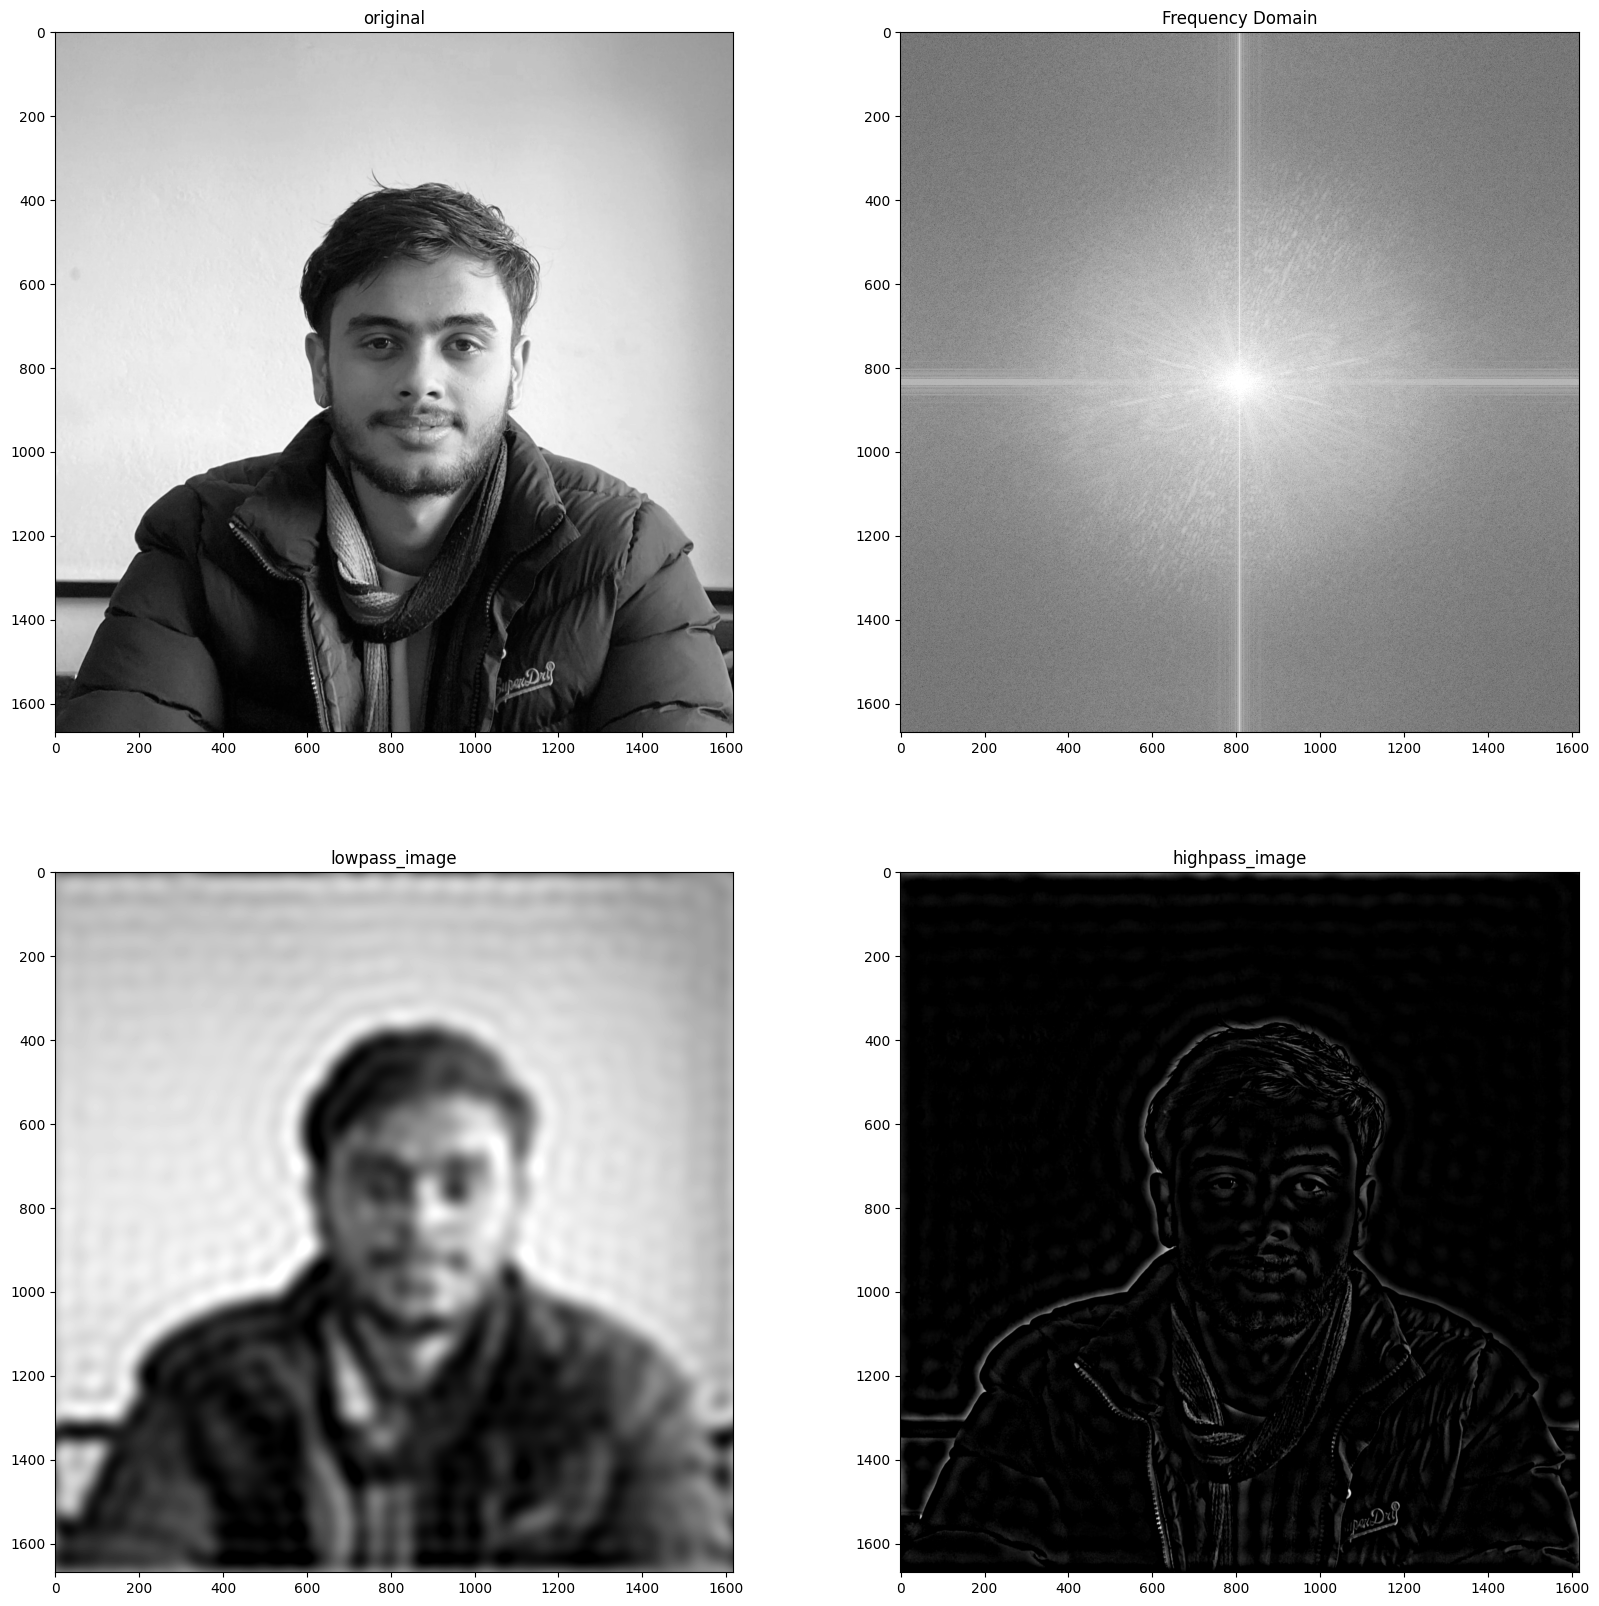

: 

In [ ]:
image = imageio.imread('img/samir.jpg', mode='F')
freq_image = frequency_image(image)
lowpass_image = low_pass_filter(image)
highpass_image = high_pass_filter(image)

fig = plt.figure()
fig.set_figheight(20)
fig.set_figwidth(20)

#plotting original image
fig.add_subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title('original')

#plotting the image in frequency domain
fig.add_subplot(2,2,2)
plt.imshow(freq_image, cmap='gray')
plt.title('Frequency Domain')

#plotting lowpass image
fig.add_subplot(2,2,3)
plt.imshow(lowpass_image, cmap='gray')
plt.title('lowpass_image')

#plotting highpass image
fig.add_subplot(2,2,4)
plt.imshow(highpass_image, cmap='gray')
plt.title('highpass_image')


# Conclusion

Frequency domain filtering provides powerful tools for image enhancement by manipulating the frequency components. Low-pass filters smooth images and reduce noise, while high-pass filters enhance edges and fine details. By applying these filters in the frequency domain and transforming the result back to the spatial domain, we can achieve effects that are difficult or inefficient to realize with spatial domain techniques alone. This lab demonstrates the practical application of Fourier-based filtering for image analysis and enhancement.